# Imports

In [98]:
import seaborn as sns
from Fcts_Base import load_adata
from Fcts_DimRed import select_dimred_features, compute_PCA, compute_DC, compute_UMAP, compute_tSNE, compute_kmeans, compute_phenograph, run_slingshot
from Fcts_Plotting import plot_random_organoids_per_cluster

In [2]:
%load_ext autoreload
%autoreload 2

# User input

In [3]:
load_dir = "/tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/2_Tables/3_QC.h5ad"


remove_feats_dimred = ["DAPI"] # List of str. Features which contain these strings are removed for the computation.

# Set up plotting parameters
fig_param = {"axes.spines.right": False,
                  "axes.spines.top": False,
                  "axes.spines.left": True,
                  "axes.spines.bottom": True,
                  "pdf.fonttype": 42,
                  "font.size": 6,
                  "axes.labelsize": 6,
                  "axes.titlesize": 8,
                  "xtick.labelsize": 6,
                  "ytick.labelsize": 6,
                  "legend.fontsize": 6}

sns.set_theme(rc = fig_param, style = "ticks")

# Load & misc
Loads AnnData object and sets up an AnnData object for dimensionality reduction based on common features across all organoids not part of remove_features

In [4]:
ad = load_adata(load_dir)

dimred_feats = select_dimred_features(ad, remove_feats_dimred)

# PCA

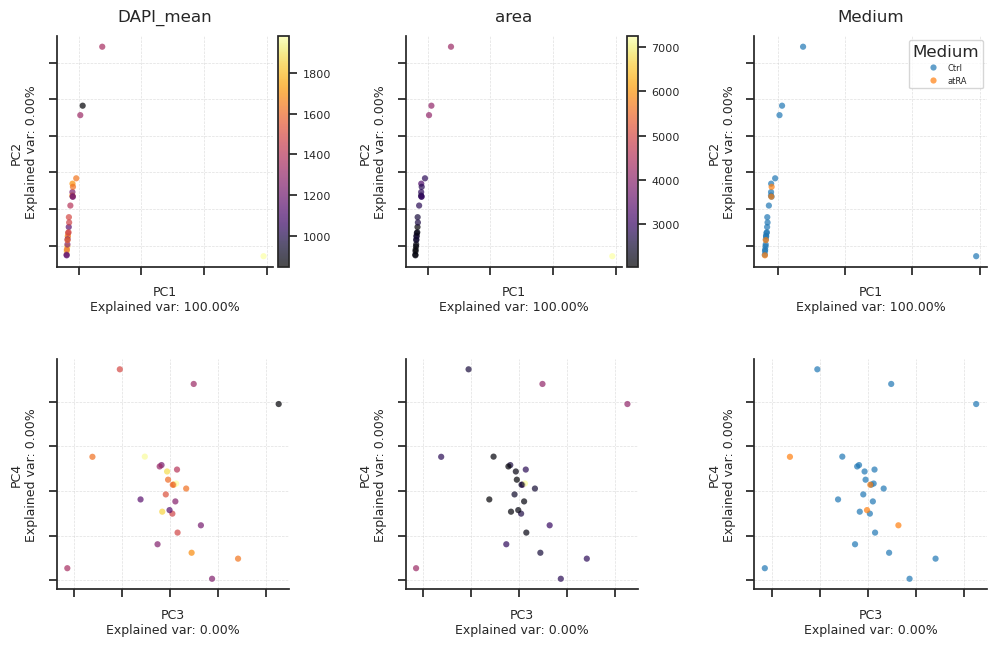

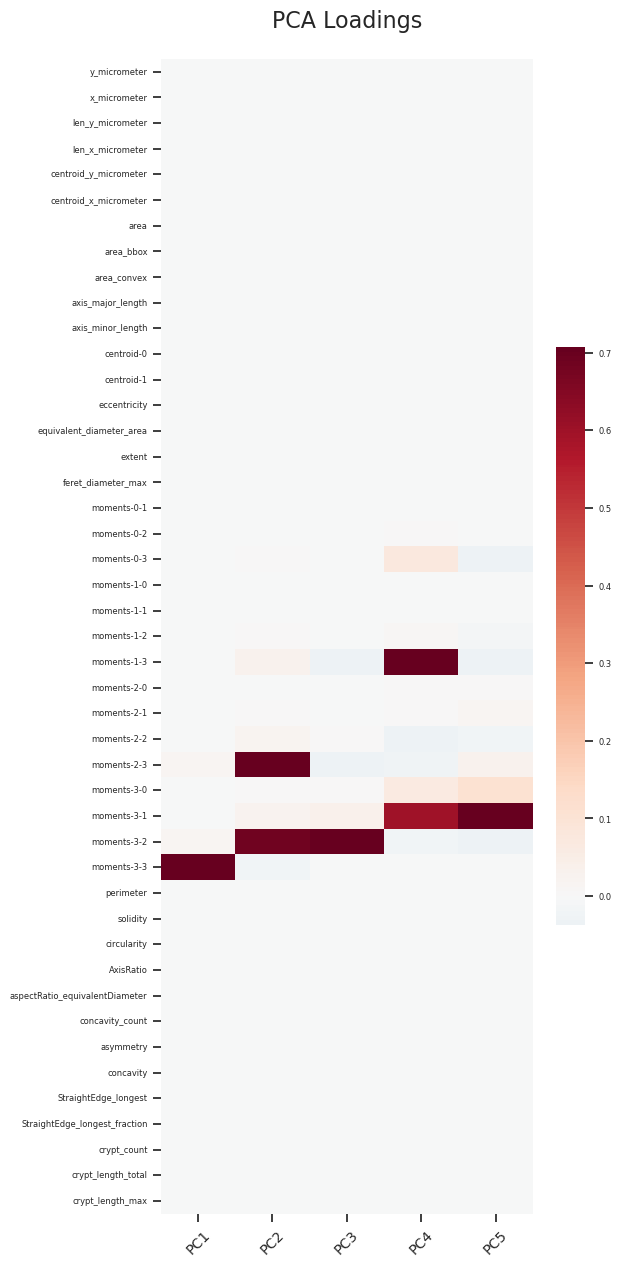

In [23]:
plot_feat = ["DAPI_mean", "area", "Medium"]
number_components = 5 # Number of PCA components to compute.
representation = None # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X.
save_plot = False

ad = compute_PCA(
    ad, 
    plot_feat, 
    number_components = number_components, 
    dimred_feats = dimred_feats, 
    representation = representation, 
    palette = "inferno", 
    save_plot = save_plot
    )

# DC

/tachyon/groups/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/1_Scripts/Fcts_DimRed.py:320: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


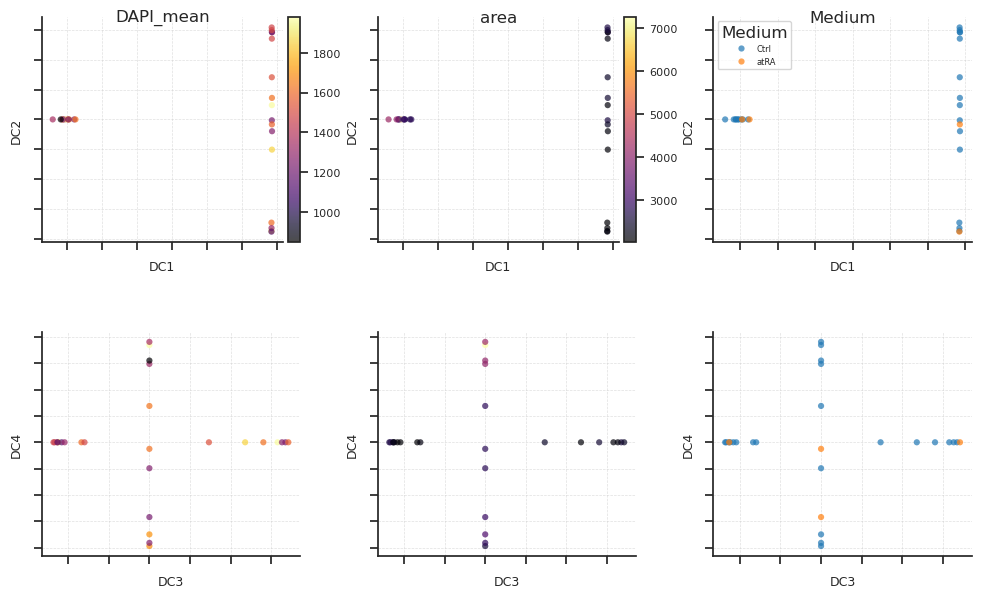

In [ ]:
plot_feat = ["DAPI_mean", "area", "Medium"]
number_components = 5 # Number of DC to compute.
representation = None # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X.
n_neighbors = 5 # Number of neighbors for the diffusion components computation.
save_plot = False

ad = compute_DC(
    ad,
    plot_feat, 
    number_components = number_components, 
    dimred_feats=dimred_feats, 
    representation = representation, 
    palette = "inferno", 
    save_plot = save_plot, 
    n_neighbors = n_neighbors
    )

# UMAP

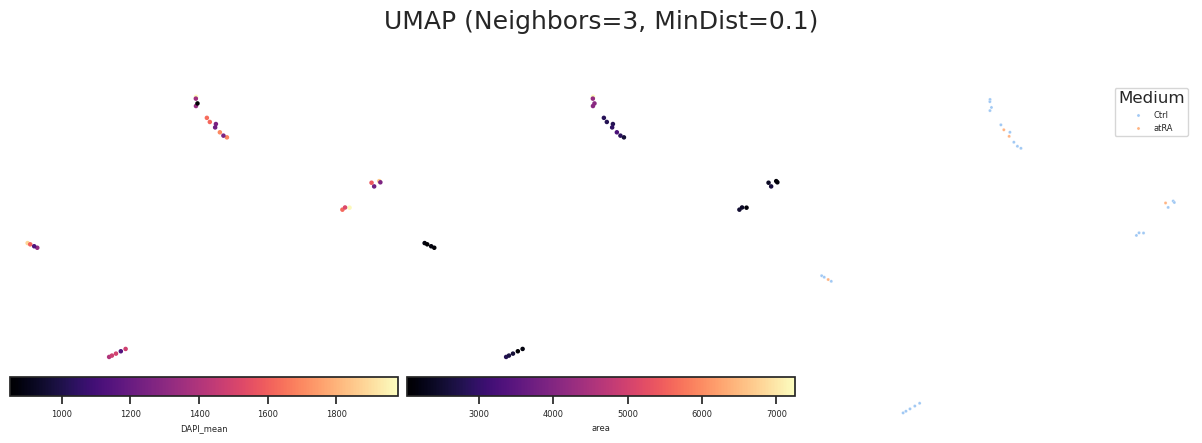

In [ ]:
plot_feat = ["DAPI_mean",  "area", "Medium"]
n_neighbors = 3 # Number of neighbors for UMAP.
min_dist = [0.1] # Minimum distances for UMAP.
representation = "X_pca" # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X.
save_plot = False

ad = compute_UMAP(ad,
    plot_feat = plot_feat, 
    n_neighbors = n_neighbors, 
    min_dist = min_dist, 
    dimred_feats = dimred_feats, 
    save_plot = save_plot, 
    representation=representation
    )

# tSNE

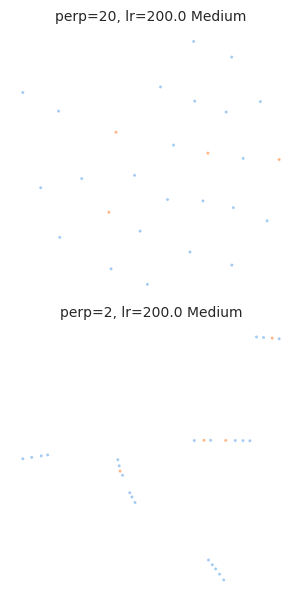

In [ ]:
plot_feat = ["Medium"] # Features to plot in the tSNE. Can be a list of features or a single feature.
perplexity = [20, 2] # Perplexity for tSNE. Can be a list of perplexities to compute multiple tSNEs.
representation = "X_pca" # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X (raw data).
save_plot = False


ad = compute_tSNE(
    ad,
    plot_feat = plot_feat,
    perplexity = perplexity,
    dimred_feats = dimred_feats,
    save_plot = save_plot,
    representation = representation,
    )

# K-Means Clustering

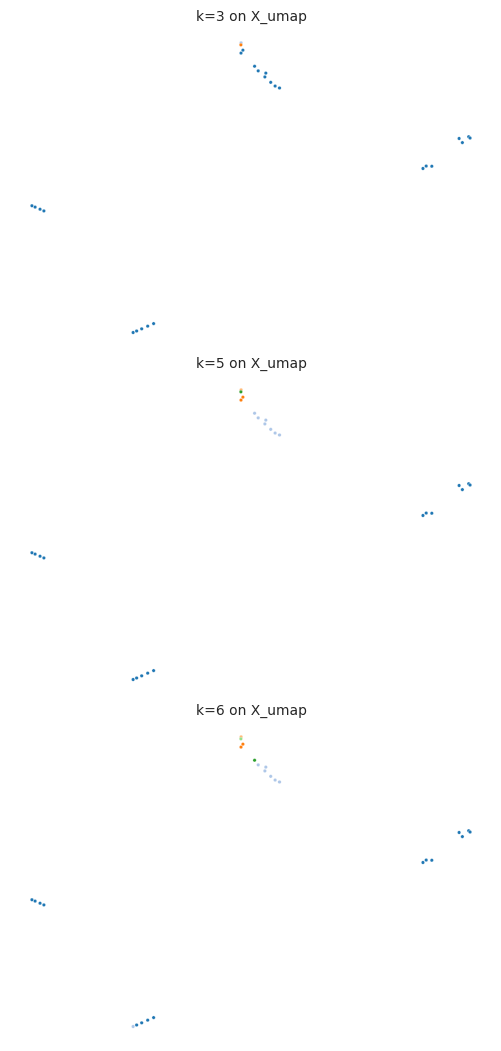

In [ ]:
n_clusters = [3, 5, 6] # Number of clusters to compute.
representation = "X_pca" # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X.
visualize_on = "X_umap"  # e.g., "X_umap", "X_tsne", "X_pca", or None to auto-pick
save_plot = False

ad = compute_kmeans(
    ad,
    n_clusters = n_clusters,
    dimred_feats = dimred_feats,
    save_plot = save_plot,
    representation = representation,
    visualize_on = visualize_on,     # e.g., "X_umap", "X_tsne", "X_pca", or None to auto-pick
    point_size = 6)

# PhenoGraph

Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.04828834533691406 seconds
Jaccard graph constructed in 1.4245781898498535 seconds
Wrote graph to binary file in 0.007100820541381836 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.47879
Louvain completed 21 runs in 0.23218894004821777 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.171884775161743 seconds


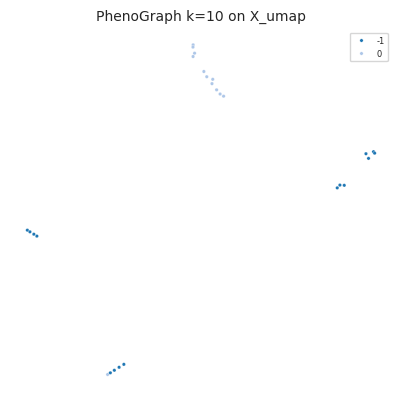

In [82]:
k = 10 # Number of neighbors for PhenoGraph. Can be a list of k values to compute multiple PhenoGraphs.
representation = "X_pca" # Key for .layers (expression matrix) or .obsm (representation, e.g. "X_pca"). If None, uses ad.X.
visualize_on = "X_umap"  # e.g., "X_umap", "X_tsne", "X_pca", or None to auto-pick
save_plot = False

ad = compute_phenograph(
    ad,
    k = k,
    dimred_feats = dimred_feats,
    save_plot = save_plot,
    representation = representation,
    visualize_on = visualize_on,
    point_size = 6)

# Plot organoids

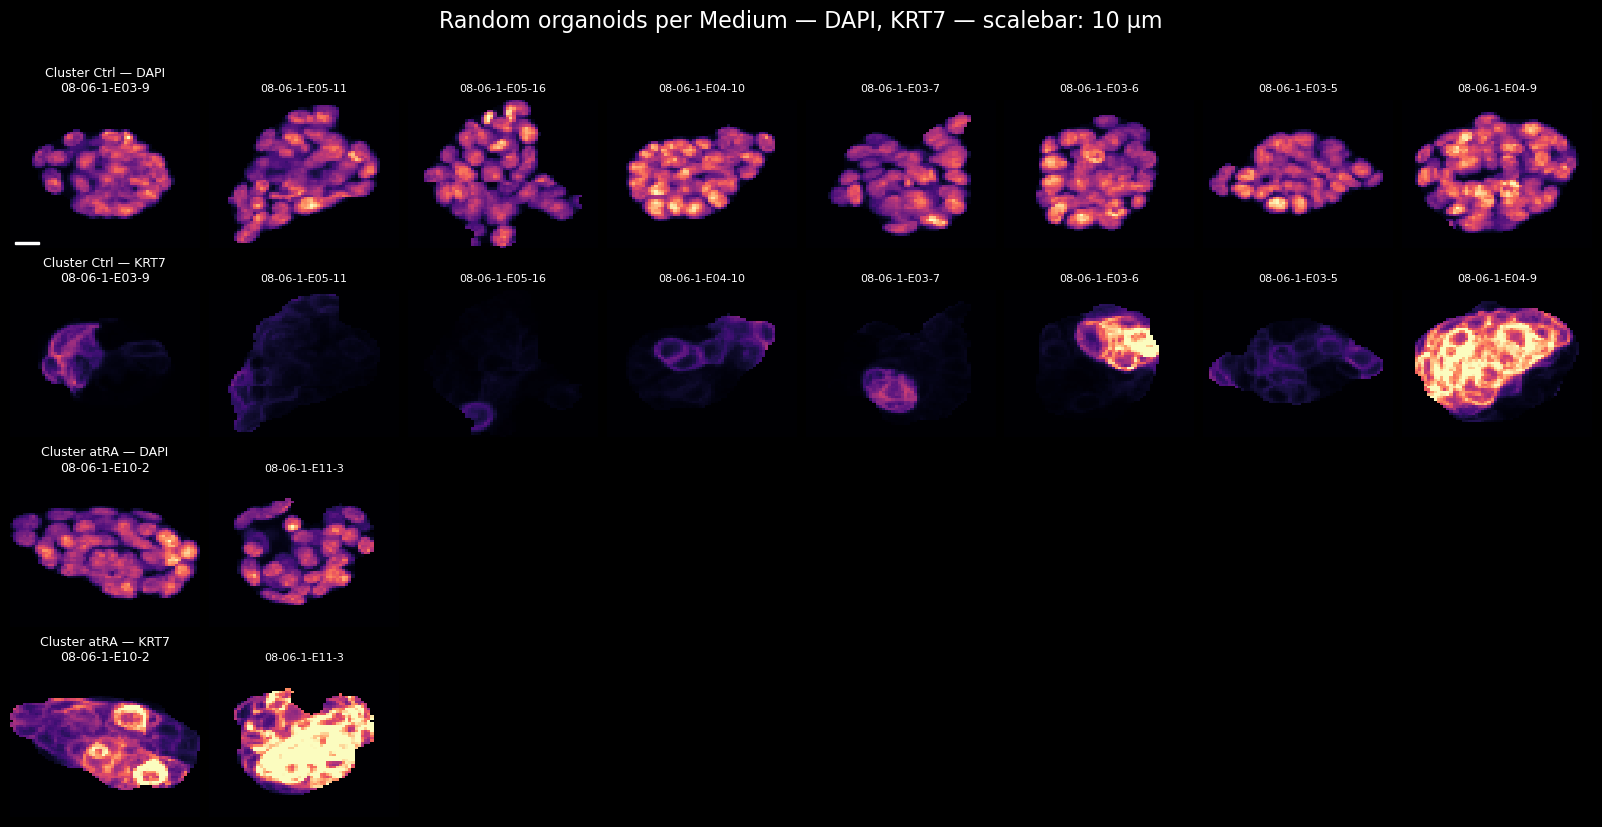

In [88]:
group_by = "Medium" # Group by this key in ad.obs.
n = 8 # Number of organoids to plot per cluster.
stainings = ["DAPI", "KRT7"] # List of stainings to plot.
thresholds = [None, (100, 20000)] # Thresholds for the stainings. Can be a list of thresholds for each staining. None leads to no thresholding.
normalize_sizes = True  # Adjusts organoid sizes to the largest organoid if True.
bar_length_um = None  # desired scalebar length in microns; if None, auto-pick a “nice” value
save_plot = False

fig = plot_random_organoids_per_cluster(
    ad,
    cluster_key = group_by,
    n_per_cluster = n,
    stainings = stainings,
    pyramid_level = 1,
    seed = 0,
    cmap="magma",
    save_plot = save_plot,
    thresholds = thresholds,
    normalize_sizes = normalize_sizes,
    bar_length_um = bar_length_um
    )

# SlingShot

/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/pyslingshot/slingshot.py:118: RuntimeWarning: Degrees of freedom <= 0 for slice
  emp_covs = np.stack([np.cov(self.data[self.cluster_label_indices == i].T) for i in range(self.num_clusters)])
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


  0%|          | 0/500 [00:00<?, ?it/s]

/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/pyslingshot/slingshot.py:322: RuntimeWarning: invalid value encountered in divide
  w_prob = cell_weights/cell_weights.sum(axis=1, keepdims=True)  # shape (cells, lineages)
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: All-NaN slice encountered
  cell_weights = z_prime / np.nanmax(z_prime, axis=1, keepdims=True) #rowMins(D) / D
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_Xenon8/lib/python3.12/site-packages/pyslingshot/slingshot.py:429: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.debug_axes[1, 0].legend()
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Prog

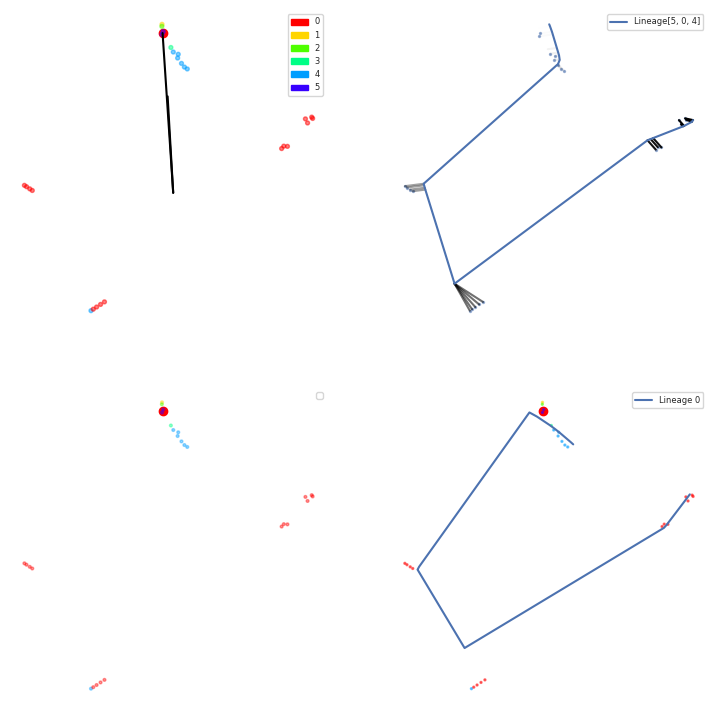

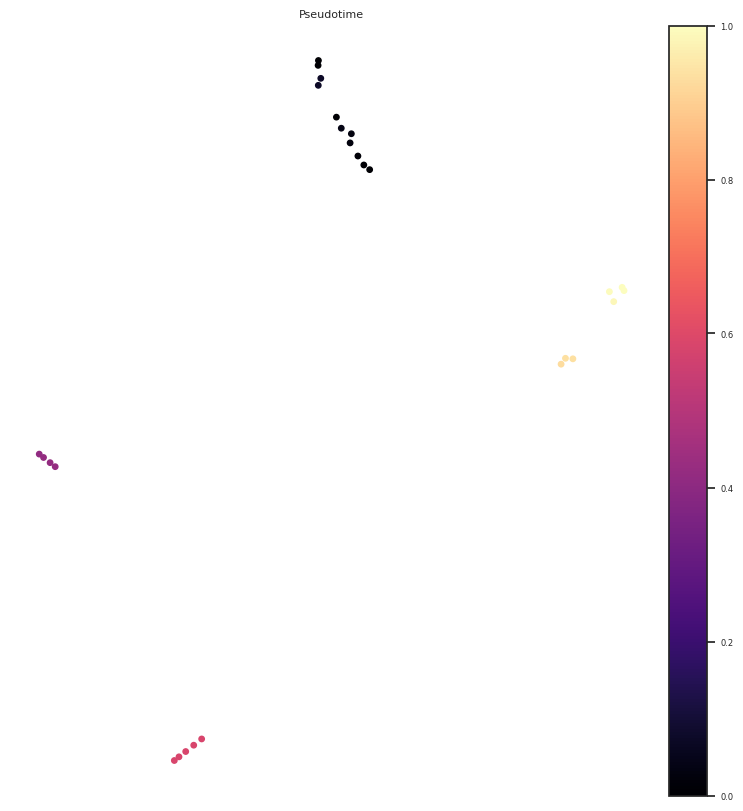

In [110]:
start_cluster = "5" # or e.g., "AB1_cluster_3" depending on labels in ad.obs[cluster_key]
save_plot = False
cluster_key = "kmeans_labels" # Column in ad.obs with cluster labels (categorical or int/str).
visualize_on = "X_umap"  # e.g., "X_umap",


ad = run_slingshot(
ad,
start_cluster = start_cluster,
num_epochs = 500,
save_plot = save_plot,
cluster_key = cluster_key,
visualize_on = visualize_on,
)

# PAGA